In [1]:
import numpy as np
numpy.random.seed(70103)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.manifold import SpectralEmbedding
from sklearn.datasets import make_s_curve

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from grakel.datasets import fetch_dataset
from grakel.kernels import ShortestPath, WeisfeilerLehman

# Problem 2

In [2]:
# Function for Laplacian eigenmap dimension reduction
def laplacian_eigenmap(X, n_components=2, n_neighbors=10):
    embedding = SpectralEmbedding(n_components=n_components, n_neighbors=n_neighbors)
    X_reduced = embedding.fit_transform(X)
    return X_reduced

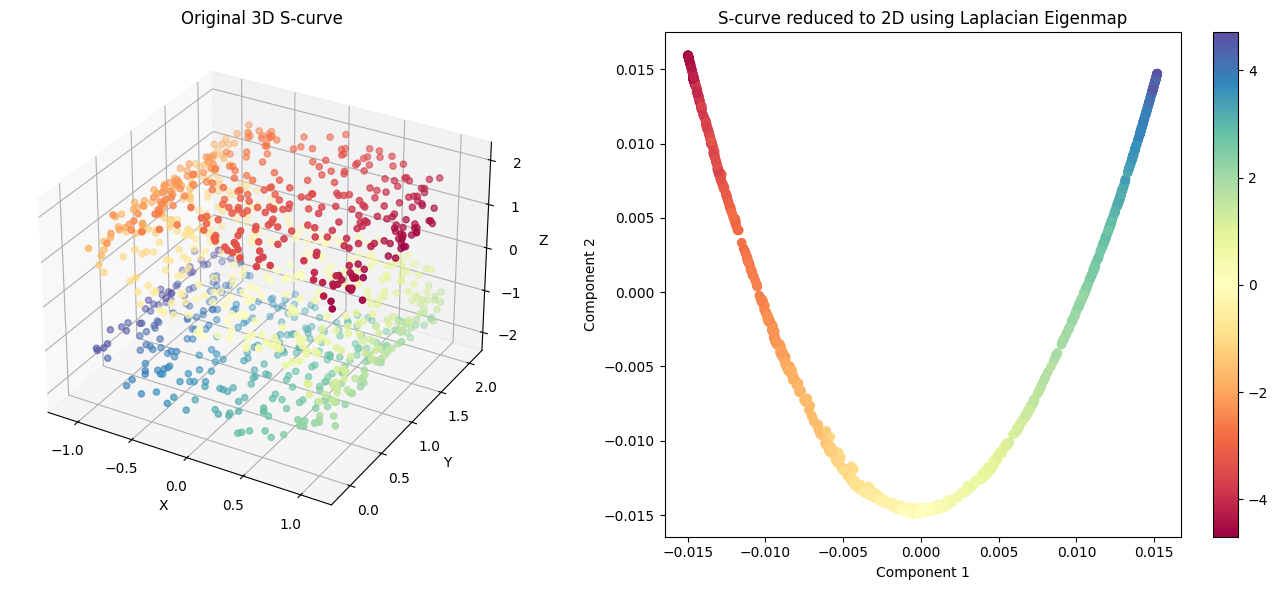

In [3]:
# Generate S-curve dataset
X, color = make_s_curve(n_samples=1000, noise=0.05)

# Apply Laplacian eigenmap to reduce S-curve to 2D
X_reduced = laplacian_eigenmap(X, n_components=2, n_neighbors=10)

fig = plt.figure(figsize=(14, 6))

# Original 3D S-curve
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original 3D S-curve")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# 2D Laplacian Eigenmap projection
ax = fig.add_subplot(1, 2, 2)
sc = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=color, cmap=plt.cm.Spectral)
plt.colorbar(sc)
ax.set_title("S-curve reduced to 2D using Laplacian Eigenmap")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

# Problem 4

In [4]:
# Load the PROTEINS dataset
PROTEINS = fetch_dataset("PROTEINS", data_home='./', verbose=False)
G, y = PROTEINS.data, PROTEINS.target

# Split the dataset into a training dataset and a test dataset
G_train, G_test, y_train, y_test = train_test_split(G, y, test_size=0.1, random_state=42)

In [5]:
# Kernel 1: Shortest Path Kernel
sp_kernel = ShortestPath(normalize=True)
K_train_sp = sp_kernel.fit_transform(G_train)
K_test_sp = sp_kernel.transform(G_test)

clf_sp = SVC(kernel="precomputed")
clf_sp.fit(K_train_sp, y_train)
y_pred_sp = clf_sp.predict(K_test_sp)
acc_sp = accuracy_score(y_test, y_pred_sp)
print("Shortest Path Kernel Accuracy:", str(round(acc_sp * 100, 2)) + "%")

Shortest Path Kernel Accuracy: 77.68%


In [6]:
# Kernel 2: Weisfeiler-Lehman Kernel
wl_kernel = WeisfeilerLehman()
K_train_wl = wl_kernel.fit_transform(G_train)
K_test_wl = wl_kernel.transform(G_test)

clf_wl = SVC(kernel="precomputed")
clf_wl.fit(K_train_wl, y_train)
y_pred_wl = clf_wl.predict(K_test_wl)
acc_wl = accuracy_score(y_test, y_pred_wl)
print("Weisfeiler-Lehman Kernel Accuracy:", str(round(acc_wl * 100, 2)) + "%")

Weisfeiler-Lehman Kernel Accuracy: 78.57%
